# Data Notebook
This notebook demonstrates how to fetch historical market capitalization for a set of tickers using the helpers in `qf/core/data.py`, visualize the results, and export them to CSV.

In [1]:
# Imports and setup
import pandas as pd
from datetime import datetime
import importlib
import qf.core.data as qdata
# Explicitly reload the core data module to reflect latest changes
importlib.reload(qdata)

from qf.core.data import (
    get_historical_market_cap,
    export_market_cap_to_csv,
    get_yahoo_query_full_data,
    get_instruments_data,
    plot_time_series,
    get_yahoo_components_for_index_symbol,
    get_yahoo_query_fundametals_hist,
    get_yahoo_query_data_hist,
)


In [2]:
# Select sample tickers (S&P 500 list intersect or explicit selection)
try:
    sp = get_instruments_data()
    tickers = sp['symbol'].head(10).tolist()  # take first 10 for demo
except Exception:
    # tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META']  # fallback list
    # tickers = ['ATO.PA', '^SBF120', '^FCHI'] 
    tickers = ['^FCHI'] 
tickers

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']

In [11]:
sp

,symbol,security_name,sector,sub_industry,date_added
0,MMM,3M,Industrials,Industrial Conglomerates,1957-03-04
1,AOS,A. O. Smith,Industrials,Building Products,2017-07-26
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,1957-03-04
3,ABBV,AbbVie,Health Care,Biotechnology,2012-12-31
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,2011-07-06
...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,2011-11-01
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,1997-10-06
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,2019-12-23
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,2001-08-07


In [4]:
# Download historical market data (daily OHLCV) for selected tickers
from qf.core.data import get_yahoo_data
import pandas as pd

# Define date range for prices
start_date_prices = '2020-01-01'
end_date_prices = pd.Timestamp.today().normalize().strftime('%Y-%m-%d')

# Single OHLCV field to retrieve
identifier = 'Close'

# Fetch prices using the helper (handles batching)
prices_df = get_yahoo_data(tickers, start_date_prices, end_date_prices, identifier=identifier)

# Sanitize index: make timezone-naive, deduplicate dates, and sort
prices_df.index = pd.to_datetime(prices_df.index, format='mixed', utc=True)
prices_df.index = prices_df.index.tz_localize(None)
prices_df = prices_df.groupby(level=0).last().sort_index()

# Preview the first rows
prices_df.head()

[*********************100%***********************]  10 of 10 completed


Ticker,A,ABBV,ABT,ACN,ADBE,AES,AFL,AMD,AOS,MMM
Date,,,,,,,,,,
2020-01-02,82.398056,69.266174,77.813858,192.515015,334.429993,15.918972,46.208546,49.099998,42.552319,120.682518
2020-01-03,81.075073,68.608681,76.865257,192.194351,331.809998,15.736185,45.888077,48.599998,42.178200,119.643280
2020-01-06,81.314735,69.150146,77.267975,190.939331,333.709991,15.918972,45.758160,48.389999,42.445423,119.757309
2020-01-07,81.564003,68.755661,76.838402,186.816940,333.390015,15.974610,45.325089,48.250000,42.160381,119.274574
2020-01-08,82.369278,69.242943,77.151634,187.183411,337.869995,15.942821,45.463673,47.830002,42.098030,121.104897


(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Time Series: MMM, AOS, ABT, ABBV, ACN, ADBE, AMD, AES, AFL, A'}, xlabel='Date', ylabel='Value (normalized)'>)

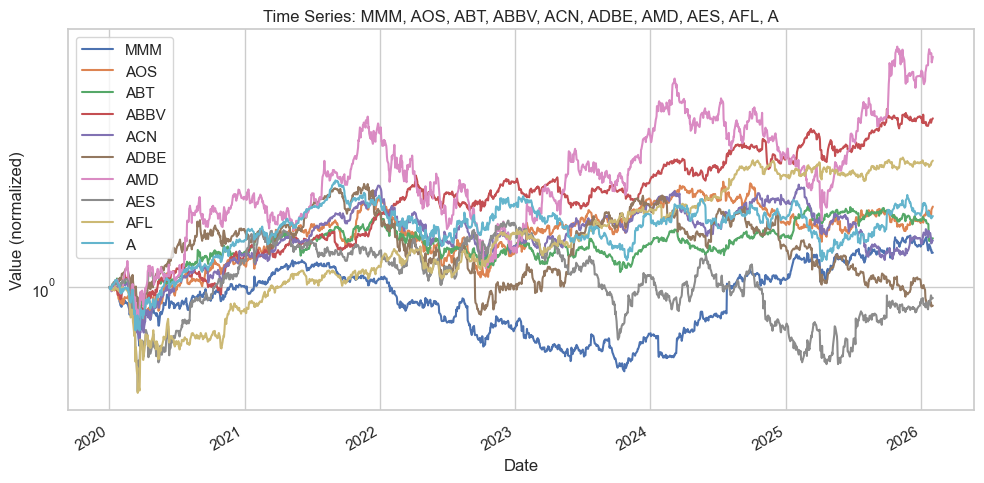

In [5]:
plot_time_series(prices_df, tickers, start_date=start_date_prices, end_date=end_date_prices, normalize=True, log_scale=True)

In [12]:
fundamentals_df = get_yahoo_query_full_data(tickers=tickers)

In [13]:
fundamentals_df

,symbol,current_price,return_on_equity,return_on_assets,debt_to_equity,current_ratio,quick_ratio,revenue,ebitda,free_cash_flow,...,fifty_two_week_change,volume,average_volume,market_cap,beta,dividend_yield,dividend_rate,ex_dividend_date,long_name,summary
0,MMM,155.68,0.75501,0.07717,268.991,1.708,0.987,24948000768,5961666560,-1.629625e+09,...,NaN,4310268,3254190,82701115392,1.166,0.0190,2.92,2025-11-14 00:00:00,3M Company,3M Company provides diversified technology ser...
1,AOS,76.34,0.29197,0.14257,10.339,1.497,0.899,3830200064,813100032,4.379625e+08,...,NaN,1540713,1325019,10697491456,1.343,0.0187,1.40,2026-01-30 00:00:00,A. O. Smith Corporation,A. O. Smith Corporation manufactures and marke...
2,ABT,109.02,0.13158,NaN,25.310,NaN,NaN,44328001536,11492666368,NaN,...,NaN,14616194,8147526,189744840704,0.751,0.0230,2.52,2026-01-15 00:00:00,Abbott Laboratories,"Abbott Laboratories, together with its subsidi..."
3,ABBV,225.66,1.37961,0.09585,NaN,0.725,0.468,59643998208,29518999552,2.079900e+10,...,NaN,5240446,6136550,398828011520,0.334,0.0295,6.65,2026-01-16 00:00:00,AbbVie Inc.,"AbbVie Inc., a research-based biopharmaceutica..."
4,ACN,241.21,0.25016,0.11125,25.694,1.411,1.290,70725558272,12458010624,1.112288e+10,...,NaN,9037875,4007968,149583708160,1.236,0.0244,6.52,2026-01-13 00:00:00,Accenture plc,Accenture plc provides strategy and consulting...
5,ADBE,271.93,0.55426,0.18221,57.266,0.996,0.877,23768999936,9242000384,8.805875e+09,...,NaN,8241572,4290296,113829896192,1.515,NaN,NaN,2005-03-24 00:00:00,Adobe Inc.,Adobe Inc. operates as a technology company wo...
6,AMD,242.11,0.05317,0.02598,6.366,2.308,1.176,32027000832,6054000128,3.245500e+09,...,NaN,41029892,39511716,394165157888,1.949,NaN,NaN,1995-04-27 01:00:00,"Advanced Micro Devices, Inc.","Advanced Micro Devices, Inc. operates as a sem..."
7,AES,16.09,0.05106,0.02269,302.896,0.723,0.376,12094000128,3206000128,-3.689875e+09,...,NaN,24641960,8134098,11458026496,0.970,0.0478,0.70,2026-01-30 00:00:00,The AES Corporation,"The AES Corporation, together with its subsidi..."
8,AFL,112.04,0.15580,0.02645,50.003,1.089,0.993,17700999168,5358000128,6.490000e+09,...,NaN,1914102,2388460,59922522112,0.662,0.0218,2.44,2026-02-18 00:00:00,Aflac Incorporated,"Aflac Incorporated, through its subsidiaries, ..."
9,A,132.14,0.20619,0.08485,52.559,1.957,1.442,6947999744,1956000000,9.985000e+08,...,NaN,2431067,1993226,37461745664,1.298,0.0075,1.02,2026-01-06 00:00:00,"Agilent Technologies, Inc.","Agilent Technologies, Inc. provides applicatio..."


In [ ]:
from yahooquery import Ticker


tq = Ticker(symbols=tickers[0], session=None)

statements = ['income_statement', 'balance_sheet', 'cash_flow']

print(tq.income_statement())

TypeError: Ticker.__init__() missing 1 required positional argument: 'symbols'

In [7]:
tq

yfinance.Ticker object <MMM>

In [ ]:
# Historical fundamentals (financial statements): tidy long format
fundamentals_hist_df = get_yahoo_query_fundametals_hist(
    tickers=tickers,
    period_type='quarter',
    output_format='long'
)



In [4]:
fundamentals_hist_df.head()

""


In [ ]:
fundamentals_hist_df

In [45]:
mc_tickers = ['ATO.PA']
# Fetch historical market cap using price * shares outstanding


In [46]:
# Fetch historical market cap using price * shares outstanding
start_date = '2020-01-01'
end_date = pd.Timestamp.today().normalize().strftime('%Y-%m-%d')
mc_df = get_historical_market_cap(mc_tickers, start_date, end_date)
mc_df.head()

[*********************100%***********************]  1 of 1 completed


,ATO.PA
Date,
2020-01-02,6.016702e+11
2020-01-03,5.987990e+11
2020-01-06,5.914616e+11
2020-01-07,6.141119e+11
2020-01-08,6.113394e+11


(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Time Series: ATO.PA'}, xlabel='Date', ylabel='Value (normalized)'>)

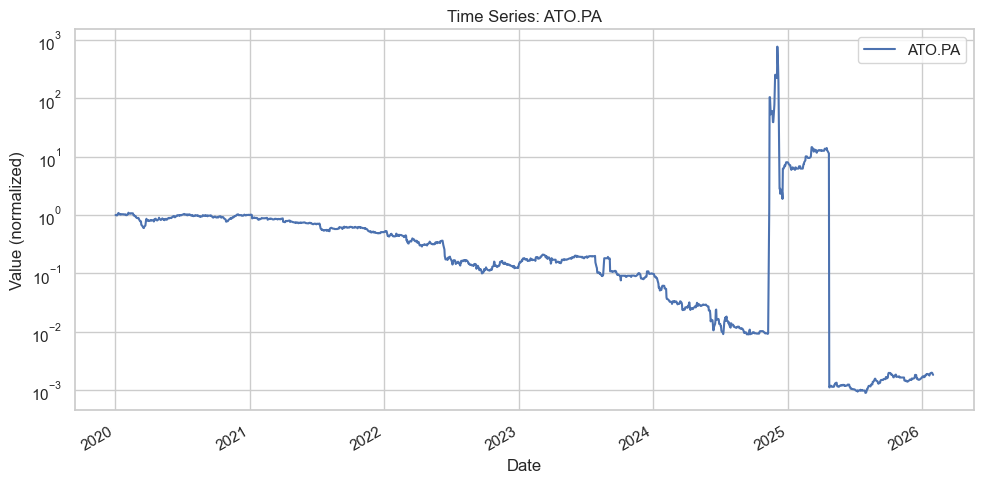

In [48]:
# Plot a few tickers (normalized for comparability)
plot_time_series(mc_df, mc_tickers, start_date=start_date, end_date=end_date, normalize=True, log_scale=True)

Atos SE (ATO.PA) is listed on Euronext Paris and is a component of the SBF 120 index. 
While historically part of the CAC 40, Atos was removed from the benchmark index in 2021 due to a drop in market capitalization. 
Key index associations and classifications:
Primary Index: SBF 120
Sector: Information Technology Services
Market: Euronext Paris (Compartment A) 
As of early 2025, the company is undergoing a restructuring process, including a reverse stock split, but remains listed on the Euronext Paris exchange. 

In [ ]:
# Export to CSV
out_path = '/Users/yevgeniy/Development/Projects/FinancialEngineering/quant-finance/data/market_cap.csv'
export_market_cap_to_csv(mc_df, out_path)
out_path

In [5]:
df = get_yahoo_components_for_index_symbol('SBF120', columns=['symbol', 'shortName'])
df.head()

/Users/yevgeniy/Development/Projects/FinancialEngineering/quant-finance/qf/core/data.py:650: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(resp.text)


,symbol
0,^SBF120
